## חיבור דמוגרפיה, קהל ותקציבים

במחברת הזו:
- טוענים את טבלת הדמוגרפיה לפי עונה
- מחברים אליה נתוני קהל לפי קבוצה ועונה
- מחברים אליה נתוני תקציב לפי קבוצה ועונה
- שומרים קבצי CSV מוכנים לניתוח המשך

הערה: נתוני התקציב אינם מלאים לכל הקבוצות בכל העונות, ולכן יישארו ערכי חסר בחלק מהשורות.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'notebooks' / 'data').exists():
            return candidate
    return current


ROOT = find_project_root()
DATA_DIR = ROOT / 'notebooks' / 'data'
DEMOGRAPHIC_DIR = DATA_DIR / 'demographic'
ATTENDANCE_DIR = DATA_DIR / 'attendance'
ECONOMIC_DIR = DATA_DIR / 'economic_data'

demographic_df = pd.read_csv(DEMOGRAPHIC_DIR / 'ligat_haal_teams_city_population_by_season.csv')
attendance_df = pd.read_csv(ATTENDANCE_DIR / 'attendance_all_seasons_ligat_haal_transfermarkt.csv')
budget_df = pd.read_csv(ECONOMIC_DIR / 'budget_data_combined_all_sources.csv')

attendance_name_map = {
    'Ihud Bnei Sakhnin': 'Bnei Sakhnin',
    'Hapoel Ramat haSharon': 'Hapoel Nir Ramat HaSharon',
    'Hapoel Rishon leZion': 'Hapoel Rishon LeZion',
    'Sekzia Ness Ziona': 'Sektzia Ness Ziona',
}

budget_name_map = {
    'Bnei Reineh': 'Maccabi Bnei Reineh',
    "Hapoel Be'er Sheva": 'Hapoel Beer Sheva',
    'Hapoel Kiryat Shmona': 'Ironi Kiryat Shmona',
    'Ironi Kiryat Shmona': 'Ironi Kiryat Shmona',
    'MS Ashdod': 'FC Ashdod',
}

attendance_prepared = attendance_df.rename(columns={'team': 'team_attendance_raw'}).copy()
attendance_prepared['club_name'] = attendance_prepared['team_attendance_raw'].replace(attendance_name_map)
for column in ['capacity', 'total_spectators', 'average_attendance']:
    attendance_prepared[column] = pd.to_numeric(attendance_prepared[column], errors='coerce')

attendance_joined_df = demographic_df.merge(
    attendance_prepared[
        ['season', 'club_name', 'team_attendance_raw', 'stadium', 'capacity', 'total_spectators', 'average_attendance']
    ],
    on=['season', 'club_name'],
    how='left',
)
attendance_joined_df['attendance_per_1000_residents'] = (
    attendance_joined_df['average_attendance'] / attendance_joined_df['population_total'] * 1000
    )
attendance_joined_df['total_spectators_per_resident'] = (
    attendance_joined_df['total_spectators'] / attendance_joined_df['population_total']
    )
attendance_joined_df['average_attendance_pct_of_population'] = (
    attendance_joined_df['average_attendance'] / attendance_joined_df['population_total'] * 100
    )
attendance_joined_df['stadium_capacity_utilization_pct'] = (
    attendance_joined_df['average_attendance'] / attendance_joined_df['capacity'] * 100
    )

budget_prepared = budget_df.rename(columns={'team_english': 'team_budget_raw'}).copy()
budget_prepared = budget_prepared[~budget_prepared['team_budget_raw'].isin(['Rest of league', 'Kiryat Shmona / Hapoel Be\'er Sheva'])].copy()
budget_prepared['club_name'] = budget_prepared['team_budget_raw'].replace(budget_name_map)
budget_prepared['budget_source_priority'] = np.where(
    budget_prepared['data_source'].astype(str).str.contains('Gemini', case=False, na=False),
    1,
    0,
    )
budget_prepared = (
    budget_prepared
    .sort_values(['season', 'club_name', 'budget_source_priority', 'budget_mid_million_nis'], ascending=[True, True, True, False])
    .drop_duplicates(['season', 'club_name'], keep='first')
    .reset_index(drop=True)
)
budget_prepared['budget_mid_nis'] = budget_prepared['budget_mid_million_nis'] * 1_000_000
budget_prepared['budget_min_nis'] = budget_prepared['budget_min_million_nis'] * 1_000_000
budget_prepared['budget_max_nis'] = budget_prepared['budget_max_million_nis'] * 1_000_000

budget_joined_df = demographic_df.merge(
    budget_prepared[
        [
            'season',
            'club_name',
            'team_budget_raw',
            'budget_min_million_nis',
            'budget_max_million_nis',
            'budget_mid_million_nis',
            'budget_min_nis',
            'budget_max_nis',
            'budget_mid_nis',
            'data_source',
            'source_note',
        ]
    ],
    on=['season', 'club_name'],
    how='left',
)
budget_joined_df['budget_nis_per_resident'] = (
    budget_joined_df['budget_mid_nis'] / budget_joined_df['population_total']
    )
budget_joined_df['budget_million_nis_per_100k_residents'] = (
    budget_joined_df['budget_mid_million_nis'] / budget_joined_df['population_total'] * 100000
    )

combined_joined_df = attendance_joined_df.merge(
    budget_joined_df[
        [
            'season',
            'club_name',
            'team_budget_raw',
            'budget_min_million_nis',
            'budget_max_million_nis',
            'budget_mid_million_nis',
            'budget_min_nis',
            'budget_max_nis',
            'budget_mid_nis',
            'data_source',
            'source_note',
            'budget_nis_per_resident',
            'budget_million_nis_per_100k_residents',
        ]
    ],
    on=['season', 'club_name'],
    how='left',
)
combined_joined_df['attendance_per_budget_million'] = (
    combined_joined_df['average_attendance'] / combined_joined_df['budget_mid_million_nis']
    )
combined_joined_df['total_spectators_per_budget_million'] = (
    combined_joined_df['total_spectators'] / combined_joined_df['budget_mid_million_nis']
    )

coverage_summary_df = (
    combined_joined_df.groupby(['season', 'season_year'], as_index=False)
    .agg(
        teams=('club_name', 'count'),
        attendance_matches=('average_attendance', lambda s: int(s.notna().sum())),
        budget_matches=('budget_mid_million_nis', lambda s: int(s.notna().sum())),
        matches_with_both=('attendance_per_budget_million', lambda s: int(s.notna().sum())),
        total_population=('population_total', 'sum'),
        total_spectators=('total_spectators', 'sum'),
        total_budget_million_nis=('budget_mid_million_nis', 'sum'),
    )
    .sort_values('season_year')
    .reset_index(drop=True)
)
coverage_summary_df['attendance_match_rate_pct'] = coverage_summary_df['attendance_matches'] / coverage_summary_df['teams'] * 100
coverage_summary_df['budget_match_rate_pct'] = coverage_summary_df['budget_matches'] / coverage_summary_df['teams'] * 100
coverage_summary_df['both_match_rate_pct'] = coverage_summary_df['matches_with_both'] / coverage_summary_df['teams'] * 100

attendance_output = DEMOGRAPHIC_DIR / 'ligat_haal_demographics_attendance_by_season.csv'
budget_output = DEMOGRAPHIC_DIR / 'ligat_haal_demographics_budget_by_season.csv'
combined_output = DEMOGRAPHIC_DIR / 'ligat_haal_demographics_attendance_budget_by_season.csv'
coverage_output = DEMOGRAPHIC_DIR / 'ligat_haal_demographics_join_coverage_by_season.csv'

attendance_joined_df.to_csv(attendance_output, index=False, encoding='utf-8-sig')
budget_joined_df.to_csv(budget_output, index=False, encoding='utf-8-sig')
combined_joined_df.to_csv(combined_output, index=False, encoding='utf-8-sig')
coverage_summary_df.to_csv(coverage_output, index=False, encoding='utf-8-sig')

print(f'Demographic rows: {len(demographic_df):,}')
print(f'Attendance join matches: {attendance_joined_df["average_attendance"].notna().sum():,}')
print(f'Budget join matches: {budget_joined_df["budget_mid_million_nis"].notna().sum():,}')
print(f'Combined rows with both: {combined_joined_df["attendance_per_budget_million"].notna().sum():,}')
print('Saved files:')
print(attendance_output)
print(budget_output)
print(combined_output)
print(coverage_output)

Demographic rows: 280
Attendance join matches: 280
Budget join matches: 120
Combined rows with both: 120
Saved files:
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_demographics_attendance_by_season.csv
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_demographics_budget_by_season.csv
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_demographics_attendance_budget_by_season.csv
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_demographics_join_coverage_by_season.csv


In [2]:
display(coverage_summary_df)

display(
    combined_joined_df[
        [
            'season',
            'club_name',
            'city_he',
            'population_total',
            'average_attendance',
            'total_spectators',
            'budget_mid_million_nis',
            'attendance_per_1000_residents',
            'budget_nis_per_resident',
            'attendance_per_budget_million',
        ]
    ].head(30)
 )

,season,season_year,teams,attendance_matches,budget_matches,matches_with_both,total_population,total_spectators,total_budget_million_nis,attendance_match_rate_pct,budget_match_rate_pct,both_match_rate_pct
0,2006/07,2006,12,12,4,4,4218651.0,119700,257.5,100.0,33.333333,33.333333
1,2007/08,2007,12,12,4,4,3834169.0,362600,257.5,100.0,33.333333,33.333333
2,2008/09,2008,12,12,4,4,4066519.0,0,232.5,100.0,33.333333,33.333333
3,2009/10,2009,16,16,4,4,4774303.0,939155,210.0,100.0,25.000000,25.000000
4,2010/11,2010,16,16,4,4,4806938.0,318450,247.5,100.0,25.000000,25.000000
5,2011/12,2011,16,16,4,4,4775966.0,911780,230.5,100.0,25.000000,25.000000
6,2012/13,2012,14,14,4,4,4148127.0,916940,247.5,100.0,28.571429,28.571429
7,2013/14,2013,14,14,4,4,4094439.0,970781,257.5,100.0,28.571429,28.571429
8,2014/15,2014,14,14,5,5,4055894.0,935937,315.5,100.0,35.714286,35.714286
9,2015/16,2015,14,14,5,5,4151239.0,1247497,351.0,100.0,35.714286,35.714286


,season,club_name,city_he,population_total,average_attendance,total_spectators,budget_mid_million_nis,attendance_per_1000_residents,budget_nis_per_resident,attendance_per_budget_million
0,2006/07,FC Ashdod,אשדוד,228562.0,2500,2500,NaN,10.937951,NaN,NaN
1,2006/07,Maccabi Herzliya,הרצלייה,110885.0,1000,1000,NaN,9.018352,NaN,NaN
2,2006/07,Maccabi Haifa,חיפה,297083.0,3850,7700,50.0,12.959341,168.303134,77.000000
3,2006/07,Beitar Jerusalem,ירושלים,1050151.0,10000,10000,135.0,9.522440,128.552941,74.074074
4,2006/07,Hapoel Kfar Saba,כפר סבא,99410.0,2250,4500,NaN,22.633538,NaN,NaN
5,2006/07,Maccabi Netanya,נתניה,234812.0,3083,9250,NaN,13.129653,NaN,NaN
6,2006/07,Hapoel Petah Tikva,פתח תקווה,270403.0,2050,10250,NaN,7.581277,NaN,NaN
7,2006/07,Maccabi Petah Tikva,פתח תקווה,270403.0,2000,2000,NaN,7.396368,NaN,NaN
8,2006/07,Hakoah Amidar Ramat Gan,רמת גן,172242.0,1250,6250,NaN,7.257231,NaN,NaN
9,2006/07,Bnei Yehuda Tel Aviv,תל אביב -יפו,494900.0,3063,49000,NaN,6.189129,NaN,NaN


## גרפים

התאים הבאים מייצרים גרפים לשאלות המרכזיות:
- האם עיר גדולה באמת מביאה יותר קהל
- האם תקציב מסביר קהל טוב יותר מגודל העיר
- איך נראה היחס בין שוק עירוני לקהל לאורך זמן
- אילו מועדונים ממקסמים קהל ביחס לגודל העיר שלהם

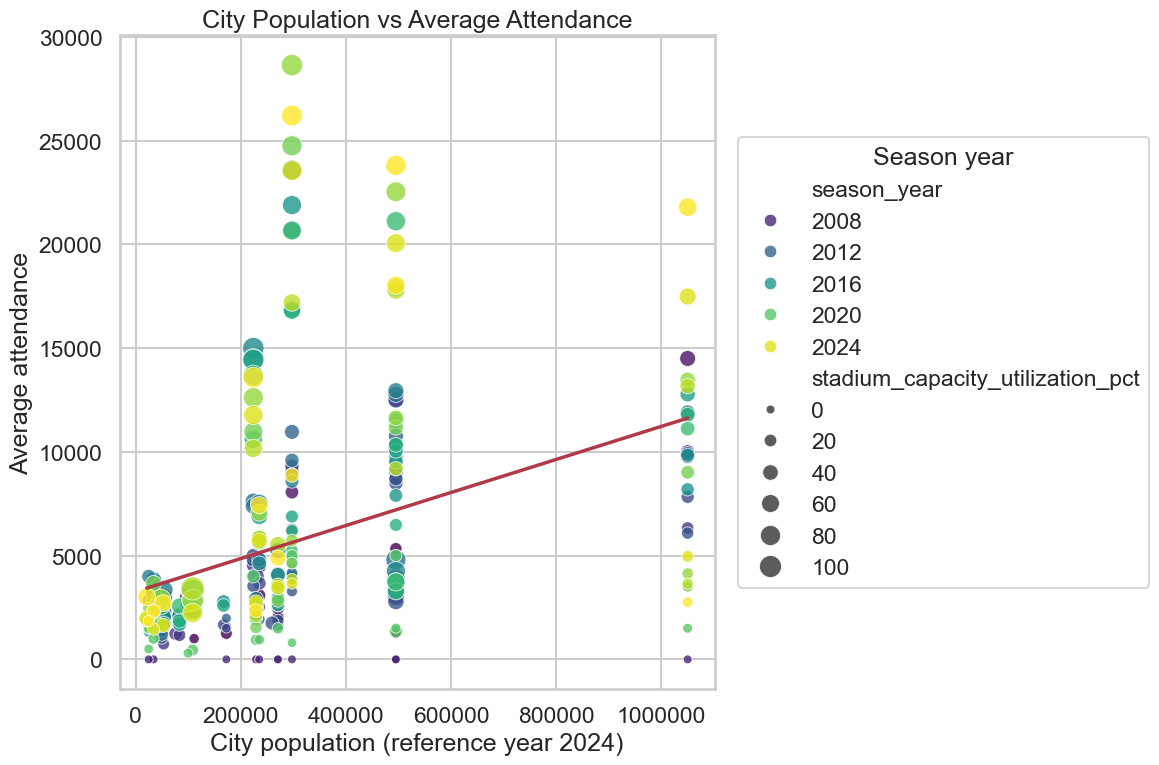

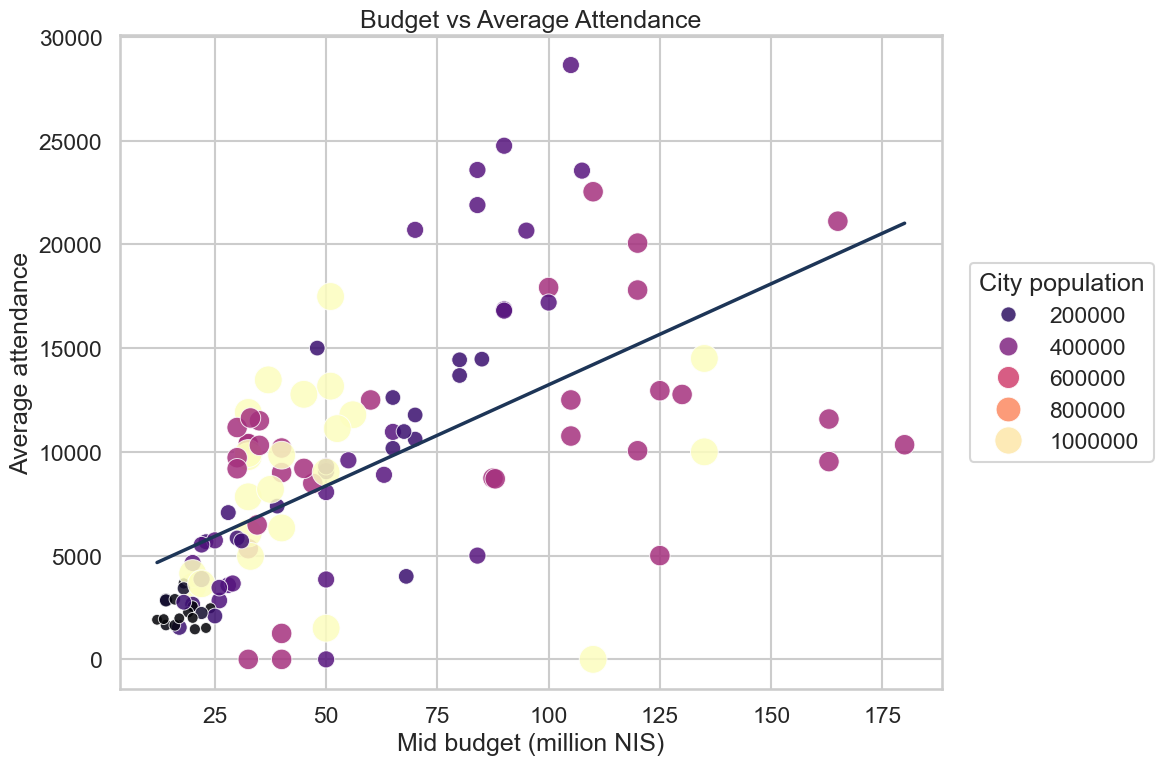

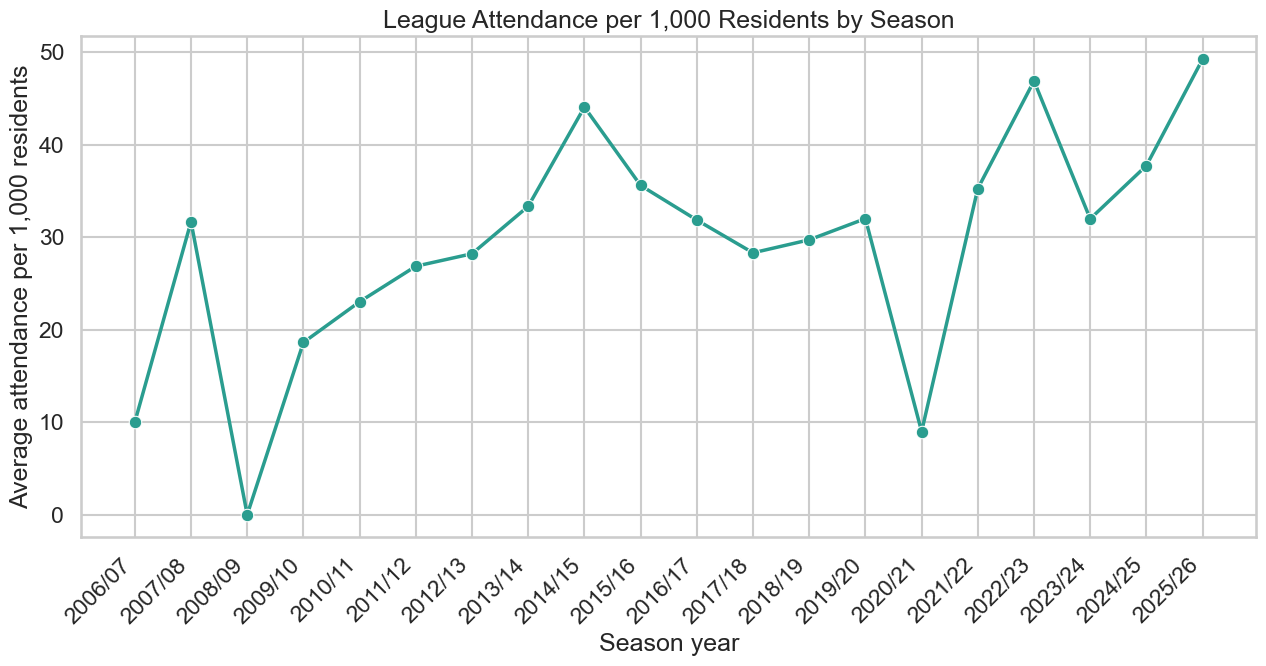

C:\Users\nitib\AppData\Local\Temp\ipykernel_32712\3360288345.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


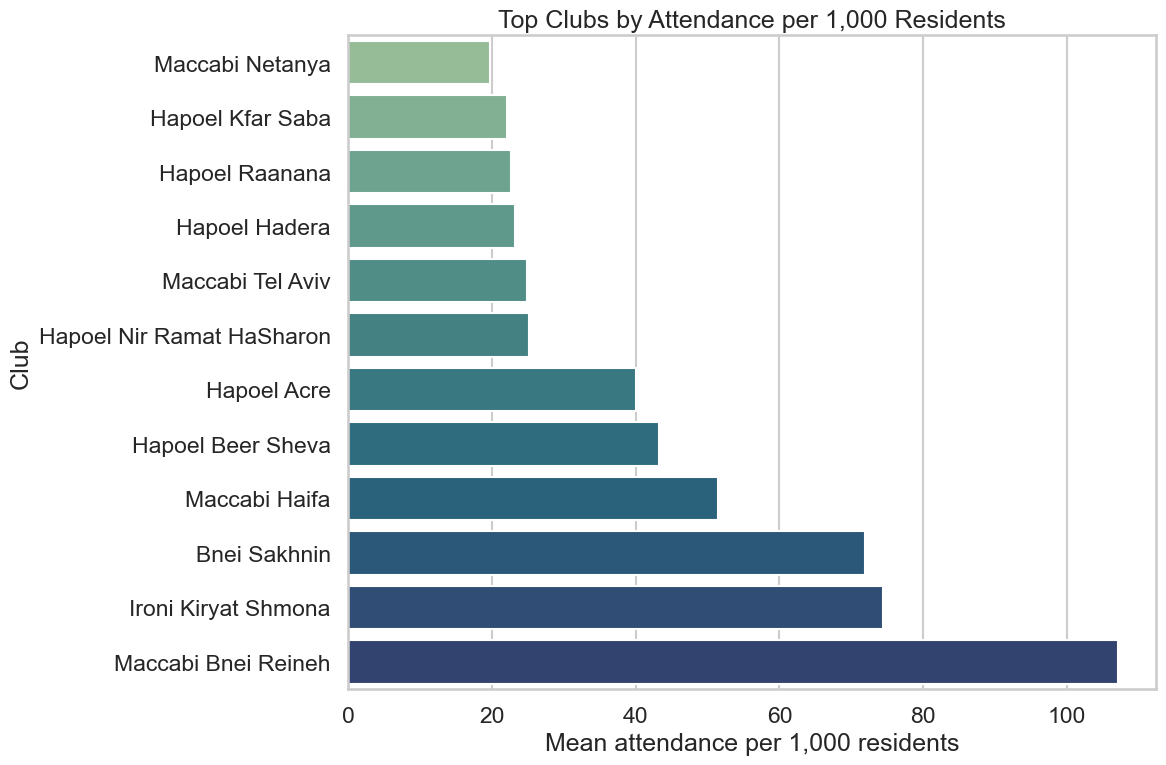

Saved demographic figures:
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\demographics_population_vs_attendance.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\demographics_budget_vs_attendance.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\demographics_attendance_per_1000_by_season.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\demographics_top_clubs_attendance_per_1000.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

FIGURES_DIR = ROOT / 'notebooks' / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')

plot_df = combined_joined_df.copy()
plot_df['season_label'] = plot_df['season']
attendance_plot_df = plot_df.dropna(subset=['population_total', 'average_attendance']).copy()
budget_plot_df = plot_df.dropna(subset=['population_total', 'average_attendance', 'budget_mid_million_nis']).copy()

fig_paths: list[Path] = []

fig, ax = plt.subplots(figsize=(12, 8))
sns.regplot(
    data=attendance_plot_df,
    x='population_total',
    y='average_attendance',
    scatter=False,
    ci=None,
    line_kws={'color': '#b23a48', 'linewidth': 2.5},
    ax=ax,
    )
sns.scatterplot(
    data=attendance_plot_df,
    x='population_total',
    y='average_attendance',
    hue='season_year',
    size='stadium_capacity_utilization_pct',
    sizes=(40, 280),
    palette='viridis',
    alpha=0.8,
    ax=ax,
    )
ax.set_title('City Population vs Average Attendance')
ax.set_xlabel('City population (reference year 2024)')
ax.set_ylabel('Average attendance')
ax.ticklabel_format(style='plain', axis='x')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Season year')
fig.tight_layout()
population_vs_attendance_path = FIGURES_DIR / 'demographics_population_vs_attendance.png'
fig.savefig(population_vs_attendance_path, dpi=200, bbox_inches='tight')
fig_paths.append(population_vs_attendance_path)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=budget_plot_df,
    x='budget_mid_million_nis',
    y='average_attendance',
    hue='population_total',
    size='population_total',
    sizes=(60, 400),
    palette='magma',
    alpha=0.85,
    ax=ax,
    )
sns.regplot(
    data=budget_plot_df,
    x='budget_mid_million_nis',
    y='average_attendance',
    scatter=False,
    ci=None,
    line_kws={'color': '#1d3557', 'linewidth': 2.5},
    ax=ax,
    )
ax.set_title('Budget vs Average Attendance')
ax.set_xlabel('Mid budget (million NIS)')
ax.set_ylabel('Average attendance')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='City population')
fig.tight_layout()
budget_vs_attendance_path = FIGURES_DIR / 'demographics_budget_vs_attendance.png'
fig.savefig(budget_vs_attendance_path, dpi=200, bbox_inches='tight')
fig_paths.append(budget_vs_attendance_path)
plt.show()
plt.close(fig)

season_metrics_df = (
    attendance_plot_df.groupby(['season', 'season_year'], as_index=False)
    .agg(
        league_avg_attendance=('average_attendance', 'mean'),
        league_attendance_per_1000=('attendance_per_1000_residents', 'mean'),
        league_capacity_utilization=('stadium_capacity_utilization_pct', 'mean'),
    )
    .sort_values('season_year')
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.lineplot(
    data=season_metrics_df,
    x='season_year',
    y='league_attendance_per_1000',
    marker='o',
    linewidth=2.5,
    color='#2a9d8f',
    ax=ax,
    )
ax.set_title('League Attendance per 1,000 Residents by Season')
ax.set_xlabel('Season year')
ax.set_ylabel('Average attendance per 1,000 residents')
ax.set_xticks(season_metrics_df['season_year'])
ax.set_xticklabels(season_metrics_df['season'], rotation=45, ha='right')
fig.tight_layout()
attendance_per_1000_path = FIGURES_DIR / 'demographics_attendance_per_1000_by_season.png'
fig.savefig(attendance_per_1000_path, dpi=200, bbox_inches='tight')
fig_paths.append(attendance_per_1000_path)
plt.show()
plt.close(fig)

club_efficiency_df = (
    attendance_plot_df.groupby('club_name', as_index=False)
    .agg(
        seasons=('season', 'nunique'),
        mean_attendance=('average_attendance', 'mean'),
        mean_attendance_per_1000=('attendance_per_1000_residents', 'mean'),
        mean_capacity_utilization=('stadium_capacity_utilization_pct', 'mean'),
    )
    .query('seasons >= 3')
    .sort_values('mean_attendance_per_1000', ascending=False)
    .head(12)
    .sort_values('mean_attendance_per_1000', ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=club_efficiency_df,
    x='mean_attendance_per_1000',
    y='club_name',
    palette='crest',
    ax=ax,
    )
ax.set_title('Top Clubs by Attendance per 1,000 Residents')
ax.set_xlabel('Mean attendance per 1,000 residents')
ax.set_ylabel('Club')
fig.tight_layout()
club_efficiency_path = FIGURES_DIR / 'demographics_top_clubs_attendance_per_1000.png'
fig.savefig(club_efficiency_path, dpi=200, bbox_inches='tight')
fig_paths.append(club_efficiency_path)
plt.show()
plt.close(fig)

print('Saved demographic figures:')
for figure_path in fig_paths:
    print(figure_path)

## מדדים למאמר

התאים הבאים בונים מדדים שאפשר לצטט ישירות במאמר:
- מתאמים בין גודל שוק, תקציב וקהל
- השוואת איכות הסבר של מודלים שונים
- מדדי ריכוז קהל לפי עונה
- דירוג מועדונים שמביאים יותר או פחות קהל מהצפוי
- אינדקסים מסכמים של ניצול שוק ויעילות תקציבית

C:\Users\nitib\AppData\Local\Temp\ipykernel_32712\1655717009.py:144: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


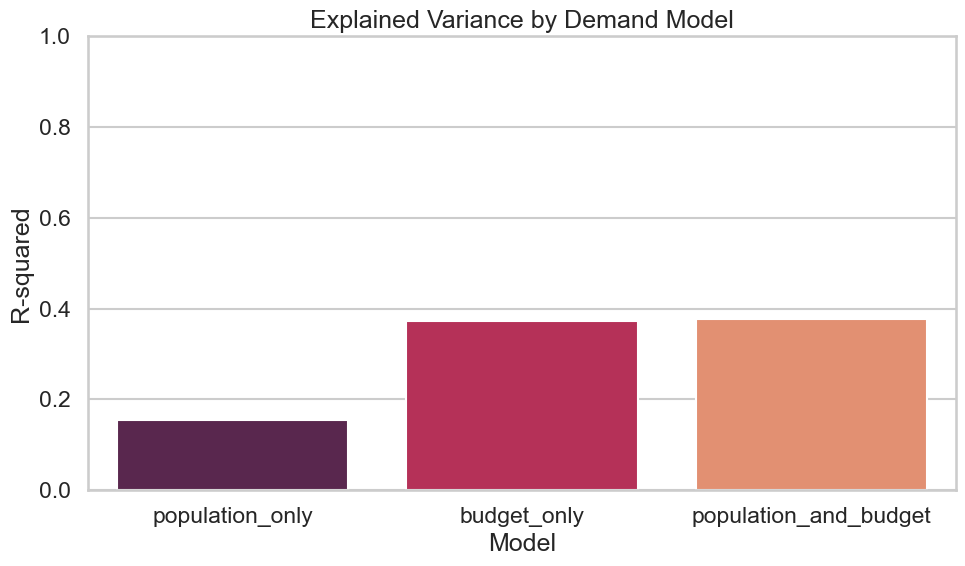

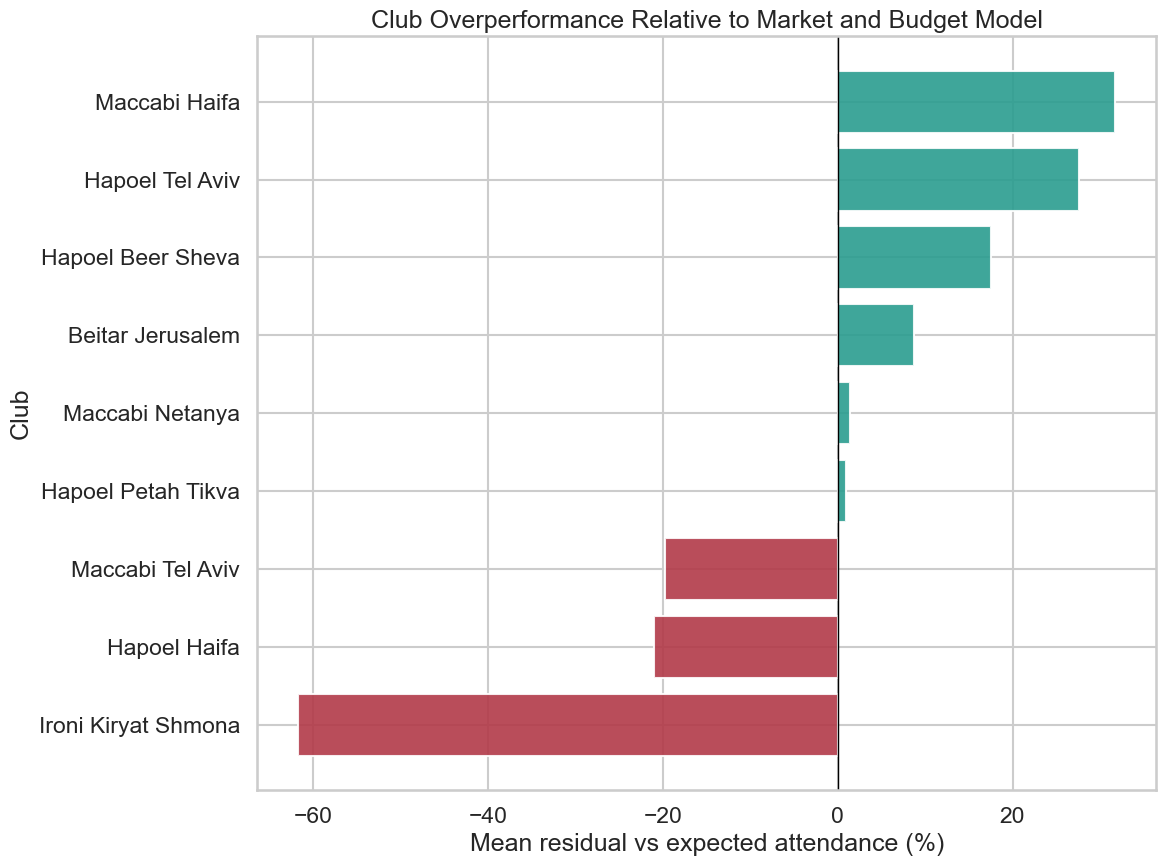

Saved paper-ready outputs:
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_paper_model_metrics.csv
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_paper_season_metrics.csv
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_paper_club_metrics.csv
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_paper_overperformers.csv
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\demographic\ligat_haal_paper_analysis_panel.csv
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\demographics_model_r_squared_comparison.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\demographics_over_under_performers.png


In [3]:
from scipy import stats


def safe_pearson(x: pd.Series, y: pd.Series) -> float:
    paired = pd.concat([x, y], axis=1).dropna()
    if len(paired) < 3:
        return np.nan
    if paired.iloc[:, 0].nunique() < 2 or paired.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(stats.pearsonr(paired.iloc[:, 0], paired.iloc[:, 1]).statistic)


def safe_spearman(x: pd.Series, y: pd.Series) -> float:
    paired = pd.concat([x, y], axis=1).dropna()
    if len(paired) < 3:
        return np.nan
    if paired.iloc[:, 0].nunique() < 2 or paired.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(stats.spearmanr(paired.iloc[:, 0], paired.iloc[:, 1]).statistic)


def safe_gini(values: pd.Series) -> float:
    array = pd.to_numeric(values, errors='coerce').dropna().to_numpy(dtype=float)
    array = array[array >= 0]
    if len(array) == 0 or np.isclose(array.sum(), 0.0):
        return np.nan
    sorted_array = np.sort(array)
    index = np.arange(1, len(sorted_array) + 1)
    return float(((2 * index - len(sorted_array) - 1) * sorted_array).sum() / (len(sorted_array) * sorted_array.sum()))


def regression_metrics(frame: pd.DataFrame, predictors: list[str], target: str) -> dict[str, float]:
    model_df = frame[predictors + [target]].dropna().copy()
    n_obs = len(model_df)
    if n_obs <= len(predictors) + 1:
        return {
            'n_obs': n_obs,
            'r_squared': np.nan,
            'adjusted_r_squared': np.nan,
            'rmse': np.nan,
        }
    X = model_df[predictors].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(model_df)), X])
    y = model_df[target].to_numpy(dtype=float)
    coefficients, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ coefficients
    residuals = y - fitted
    sse = float(np.sum(residuals ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r_squared = np.nan if np.isclose(sst, 0.0) else 1 - (sse / sst)
    adjusted_r_squared = np.nan
    if n_obs > len(predictors) + 1 and not np.isnan(r_squared):
        adjusted_r_squared = 1 - (1 - r_squared) * (n_obs - 1) / (n_obs - len(predictors) - 1)
    rmse = float(np.sqrt(np.mean(residuals ** 2)))
    return {
        'n_obs': n_obs,
        'r_squared': r_squared,
        'adjusted_r_squared': adjusted_r_squared,
        'rmse': rmse,
        'intercept': float(coefficients[0]),
        **{f'beta_{predictor}': float(coefficients[idx + 1]) for idx, predictor in enumerate(predictors)},
    }


def add_regression_outputs(frame: pd.DataFrame, predictors: list[str], target: str, prefix: str) -> tuple[pd.DataFrame, dict[str, float]]:
    metrics = regression_metrics(frame, predictors, target)
    output_df = frame.copy()
    prediction_col = f'predicted_{prefix}'
    residual_col = f'residual_{prefix}'
    ratio_col = f'residual_pct_{prefix}'
    output_df[prediction_col] = np.nan
    output_df[residual_col] = np.nan
    output_df[ratio_col] = np.nan
    model_df = output_df[predictors + [target]].dropna().copy()
    if len(model_df) <= len(predictors) + 1:
        return output_df, metrics
    X = model_df[predictors].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(model_df)), X])
    coefficients, _, _, _ = np.linalg.lstsq(X, model_df[target].to_numpy(dtype=float), rcond=None)
    fitted = X @ coefficients
    output_df.loc[model_df.index, prediction_col] = fitted
    output_df.loc[model_df.index, residual_col] = model_df[target].to_numpy(dtype=float) - fitted
    output_df.loc[model_df.index, ratio_col] = np.where(
        np.isclose(fitted, 0.0),
        np.nan,
        (model_df[target].to_numpy(dtype=float) - fitted) / fitted * 100,
    )
    return output_df, metrics


paper_df = combined_joined_df.copy()
paper_df, population_model_metrics = add_regression_outputs(
    paper_df,
    predictors=['population_total'],
    target='average_attendance',
    prefix='population_model',
)
paper_df, budget_model_metrics = add_regression_outputs(
    paper_df,
    predictors=['budget_mid_million_nis'],
    target='average_attendance',
    prefix='budget_model',
)
paper_df, combined_model_metrics = add_regression_outputs(
    paper_df,
    predictors=['population_total', 'budget_mid_million_nis'],
    target='average_attendance',
    prefix='market_budget_model',
)

overall_metrics_rows = [
    {
        'model': 'population_only',
        'sample': 'all club-seasons with attendance',
        'pearson_correlation': safe_pearson(paper_df['population_total'], paper_df['average_attendance']),
        'spearman_correlation': safe_spearman(paper_df['population_total'], paper_df['average_attendance']),
        **population_model_metrics,
    },
    {
        'model': 'budget_only',
        'sample': 'club-seasons with attendance and budget',
        'pearson_correlation': safe_pearson(paper_df['budget_mid_million_nis'], paper_df['average_attendance']),
        'spearman_correlation': safe_spearman(paper_df['budget_mid_million_nis'], paper_df['average_attendance']),
        **budget_model_metrics,
    },
    {
        'model': 'population_and_budget',
        'sample': 'club-seasons with attendance, population, and budget',
        'pearson_correlation': safe_pearson(
            paper_df.dropna(subset=['budget_mid_million_nis'])['population_total'],
            paper_df.dropna(subset=['budget_mid_million_nis'])['average_attendance'],
        ),
        'spearman_correlation': safe_spearman(
            paper_df.dropna(subset=['budget_mid_million_nis'])['population_total'],
            paper_df.dropna(subset=['budget_mid_million_nis'])['average_attendance'],
        ),
        **combined_model_metrics,
    },
]
overall_model_metrics_df = pd.DataFrame(overall_metrics_rows)

season_paper_metrics_df = (
    paper_df.groupby(['season', 'season_year'], as_index=False)
    .apply(
        lambda season_group: pd.Series({
            'teams': int(season_group['club_name'].nunique()),
            'budget_coverage_pct': float(season_group['budget_mid_million_nis'].notna().mean() * 100),
            'mean_attendance': float(season_group['average_attendance'].mean()),
            'median_attendance': float(season_group['average_attendance'].median()),
            'attendance_gini': safe_gini(season_group['average_attendance']),
            'attendance_hhi': float(((season_group['total_spectators'].fillna(0) / season_group['total_spectators'].fillna(0).sum()) ** 2).sum()) if season_group['total_spectators'].fillna(0).sum() > 0 else np.nan,
            'top_4_attendance_share_pct': float(season_group['total_spectators'].fillna(0).nlargest(4).sum() / season_group['total_spectators'].fillna(0).sum() * 100) if season_group['total_spectators'].fillna(0).sum() > 0 else np.nan,
            'mean_attendance_per_1000': float(season_group['attendance_per_1000_residents'].mean()),
            'mean_capacity_utilization_pct': float(season_group['stadium_capacity_utilization_pct'].mean()),
            'population_attendance_pearson': safe_pearson(season_group['population_total'], season_group['average_attendance']),
            'budget_attendance_pearson': safe_pearson(season_group['budget_mid_million_nis'], season_group['average_attendance']),
        })
    )
    .sort_values('season_year')
    .reset_index(drop=True)
)

club_paper_metrics_df = (
    paper_df.groupby('club_name', as_index=False)
    .agg(
        seasons=('season', 'nunique'),
        mean_population=('population_total', 'mean'),
        mean_attendance=('average_attendance', 'mean'),
        median_attendance=('average_attendance', 'median'),
        mean_total_spectators=('total_spectators', 'mean'),
        mean_attendance_per_1000=('attendance_per_1000_residents', 'mean'),
        mean_total_spectators_per_resident=('total_spectators_per_resident', 'mean'),
        mean_capacity_utilization_pct=('stadium_capacity_utilization_pct', 'mean'),
        mean_budget_mid_million_nis=('budget_mid_million_nis', 'mean'),
        mean_budget_nis_per_resident=('budget_nis_per_resident', 'mean'),
        mean_attendance_per_budget_million=('attendance_per_budget_million', 'mean'),
        mean_population_model_residual=('residual_population_model', 'mean'),
        mean_market_budget_model_residual=('residual_market_budget_model', 'mean'),
        mean_market_budget_model_residual_pct=('residual_pct_market_budget_model', 'mean'),
    )
    .query('seasons >= 3')
    .reset_index(drop=True)
)

for score_column in [
    'mean_attendance_per_1000',
    'mean_capacity_utilization_pct',
    'mean_attendance_per_budget_million',
    'mean_market_budget_model_residual_pct',
]:
    standardized = club_paper_metrics_df[score_column]
    club_paper_metrics_df[f'z_{score_column}'] = (standardized - standardized.mean()) / standardized.std(ddof=0)

club_paper_metrics_df['market_capture_index'] = club_paper_metrics_df[[
    'z_mean_attendance_per_1000',
    'z_mean_capacity_utilization_pct',
    'z_mean_market_budget_model_residual_pct',
]].mean(axis=1)

club_paper_metrics_df['budget_efficiency_index'] = club_paper_metrics_df[[
    'z_mean_attendance_per_budget_million',
    'z_mean_market_budget_model_residual_pct',
]].mean(axis=1)

club_paper_metrics_df = club_paper_metrics_df.sort_values('market_capture_index', ascending=False).reset_index(drop=True)

overperformers_df = club_paper_metrics_df[
    [
        'club_name',
        'seasons',
        'mean_attendance',
        'mean_attendance_per_1000',
        'mean_capacity_utilization_pct',
        'mean_budget_mid_million_nis',
        'mean_market_budget_model_residual',
        'mean_market_budget_model_residual_pct',
        'market_capture_index',
        'budget_efficiency_index',
    ]
].sort_values('mean_market_budget_model_residual_pct', ascending=False).reset_index(drop=True)

paper_metrics_output = DEMOGRAPHIC_DIR / 'ligat_haal_paper_model_metrics.csv'
season_metrics_output = DEMOGRAPHIC_DIR / 'ligat_haal_paper_season_metrics.csv'
club_metrics_output = DEMOGRAPHIC_DIR / 'ligat_haal_paper_club_metrics.csv'
overperformers_output = DEMOGRAPHIC_DIR / 'ligat_haal_paper_overperformers.csv'
paper_panel_output = DEMOGRAPHIC_DIR / 'ligat_haal_paper_analysis_panel.csv'

overall_model_metrics_df.to_csv(paper_metrics_output, index=False, encoding='utf-8-sig')
season_paper_metrics_df.to_csv(season_metrics_output, index=False, encoding='utf-8-sig')
club_paper_metrics_df.to_csv(club_metrics_output, index=False, encoding='utf-8-sig')
overperformers_df.to_csv(overperformers_output, index=False, encoding='utf-8-sig')
paper_df.to_csv(paper_panel_output, index=False, encoding='utf-8-sig')

model_compare_plot = overall_model_metrics_df[['model', 'r_squared']].dropna().copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=model_compare_plot, x='model', y='r_squared', hue='model', dodge=False, palette='rocket', ax=ax)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.set_title('Explained Variance by Demand Model')
ax.set_xlabel('Model')
ax.set_ylabel('R-squared')
ax.set_ylim(0, max(1, model_compare_plot['r_squared'].max() * 1.15))
fig.tight_layout()
model_compare_path = FIGURES_DIR / 'demographics_model_r_squared_comparison.png'
fig.savefig(model_compare_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

top_bottom_overperformers_df = pd.concat([
    overperformers_df.head(8),
    overperformers_df.tail(8),
]).drop_duplicates().sort_values('mean_market_budget_model_residual_pct').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 9))
bar_colors = ['#b23a48' if value < 0 else '#2a9d8f' for value in top_bottom_overperformers_df['mean_market_budget_model_residual_pct']]
ax.barh(
    top_bottom_overperformers_df['club_name'],
    top_bottom_overperformers_df['mean_market_budget_model_residual_pct'],
    color=bar_colors,
    alpha=0.9,
    )
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Club Overperformance Relative to Market and Budget Model')
ax.set_xlabel('Mean residual vs expected attendance (%)')
ax.set_ylabel('Club')
fig.tight_layout()
overperformers_fig_path = FIGURES_DIR / 'demographics_over_under_performers.png'
fig.savefig(overperformers_fig_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

print('Saved paper-ready outputs:')
for output_path in [
    paper_metrics_output,
    season_metrics_output,
    club_metrics_output,
    overperformers_output,
    paper_panel_output,
    model_compare_path,
    overperformers_fig_path,
]:
    print(output_path)

In [ ]:
display(overall_model_metrics_df)
display(season_paper_metrics_df)
display(overperformers_df.head(15))